In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:\\Users\\HP\\Downloads\\Synthetic.csv")

In [3]:
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [4]:
# Drop unnecessary index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

In [5]:
df.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


In [22]:
# Extract feature (X) and target (y)
X_raw = df["X"].values.reshape(-1, 1)
y = df["Y"].values.reshape(-1, 1)

In [23]:
# Z-score standardization of feature X
X_std = (X_raw - np.mean(X_raw)) / np.std(X_raw)

In [24]:
# Add intercept column (column of ones) to design matrix X
X = np.hstack((np.ones((X_std.shape[0], 1)), X_std))
n, d = X.shape

In [25]:
def linear_function(X, theta):
    """Computes y_hat = X * theta"""
    return np.dot(X, theta)

def mean_squared_error(y_true, y_hat):
    """Computes Mean Squared Error loss"""
    return np.mean((y_true - y_hat) ** 2)

def initialize_theta(dimensions):
    """Initializes weights (theta) to zeros"""
    return np.zeros((dimensions, 1))

def compute_gradient(X, y, theta):
    """Computes matrix gradient for batch MSE loss"""
    return -2.0 * np.dot(X.T, (y - linear_function(X, theta))) / X.shape[0]

def update_parameters(theta, grads, learning_rate):
    """Updates parameters using gradient descent rule"""
    return theta - learning_rate * grads

def shuffle_data(X, y):
    """Randomly shuffles data rows"""
    shuffled_idx = np.random.permutation(X.shape[0])
    return X[shuffled_idx], y[shuffled_idx]

In [26]:
class GradientDescent:
    def __init__(self, learning_rate=0.01, num_epochs=1000, tolerance=1e-5):
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.tolerance = tolerance

    def vanilla_batch(self, X, y):
        """Batch (Vanilla) Gradient Descent"""
        n, d = X.shape
        theta = initialize_theta(d)
        losses = []

        for epoch in range(self.num_epochs):
            y_pred = linear_function(X, theta)
            loss = mean_squared_error(y, y_pred)
            losses.append(loss)

            grads = compute_gradient(X, y, theta)
            theta = update_parameters(theta, grads, self.learning_rate)

            if loss < self.tolerance:
                break

        return theta, losses

    def stochastic(self, X, y):
        """Stochastic Gradient Descent (SGD)"""
        n, d = X.shape
        theta = initialize_theta(d)
        losses = []

        for epoch in range(self.num_epochs):
            X_shuffled, y_shuffled = shuffle_data(X, y)
            running_loss = 0.0

            for i in range(n):
                sample_x = X_shuffled[i:i+1]
                sample_y = y_shuffled[i:i+1]

                y_pred = linear_function(sample_x, theta)
                loss = mean_squared_error(sample_y, y_pred)
                running_loss += loss

                grads = -2.0 * sample_x.T * (sample_y - y_pred)
                theta = update_parameters(theta, grads, self.learning_rate)

            avg_loss = running_loss / n
            losses.append(avg_loss)

            if avg_loss < self.tolerance:
                break

        return theta, losses

    def mini_batch(self, X, y, batch_size=10):
        """Mini-Batch Gradient Descent"""
        n, d = X.shape
        theta = initialize_theta(d)
        losses = []

        for epoch in range(self.num_epochs):
            X_shuffled, y_shuffled = shuffle_data(X, y)
            running_loss = 0.0

            for batch_idx in range(0, n, batch_size):
                x_batch = X_shuffled[batch_idx:batch_idx + batch_size]
                y_batch = y_shuffled[batch_idx:batch_idx + batch_size]

                y_pred = linear_function(x_batch, theta)
                loss = mean_squared_error(y_batch, y_pred)

                grads = compute_gradient(x_batch, y_batch, theta)
                theta = update_parameters(theta, grads, self.learning_rate)

                running_loss += loss * x_batch.shape[0]

            avg_loss = running_loss / n
            losses.append(avg_loss)

            if avg_loss < self.tolerance:
                break

        return theta, losses

In [32]:
trainer = GradientDescent(learning_rate=0.01, num_epochs=1000)

theta_batch, loss_batch = trainer.vanilla_batch(X, y)
theta_sgd, loss_sgd = trainer.stochastic(X, y)
theta_mb, loss_mb = trainer.mini_batch(X, y, batch_size=10)

print(f"Batch GD Parameters:      Intercept = {theta_batch[0][0]:.4f}, Slope = {theta_batch[1][0]:.4f}")
print(f"Stochastic GD Parameters: Intercept = {theta_sgd[0][0]:.4f}, Slope = {theta_sgd[1][0]:.4f}")
print(f"Mini-Batch GD Parameters: Intercept = {theta_mb[0][0]:.4f}, Slope = {theta_mb[1][0]:.4f}")

Batch GD Parameters:      Intercept = 140.7477, Slope = 85.1550
Stochastic GD Parameters: Intercept = 140.9865, Slope = 85.3301
Mini-Batch GD Parameters: Intercept = 140.7418, Slope = 85.1443


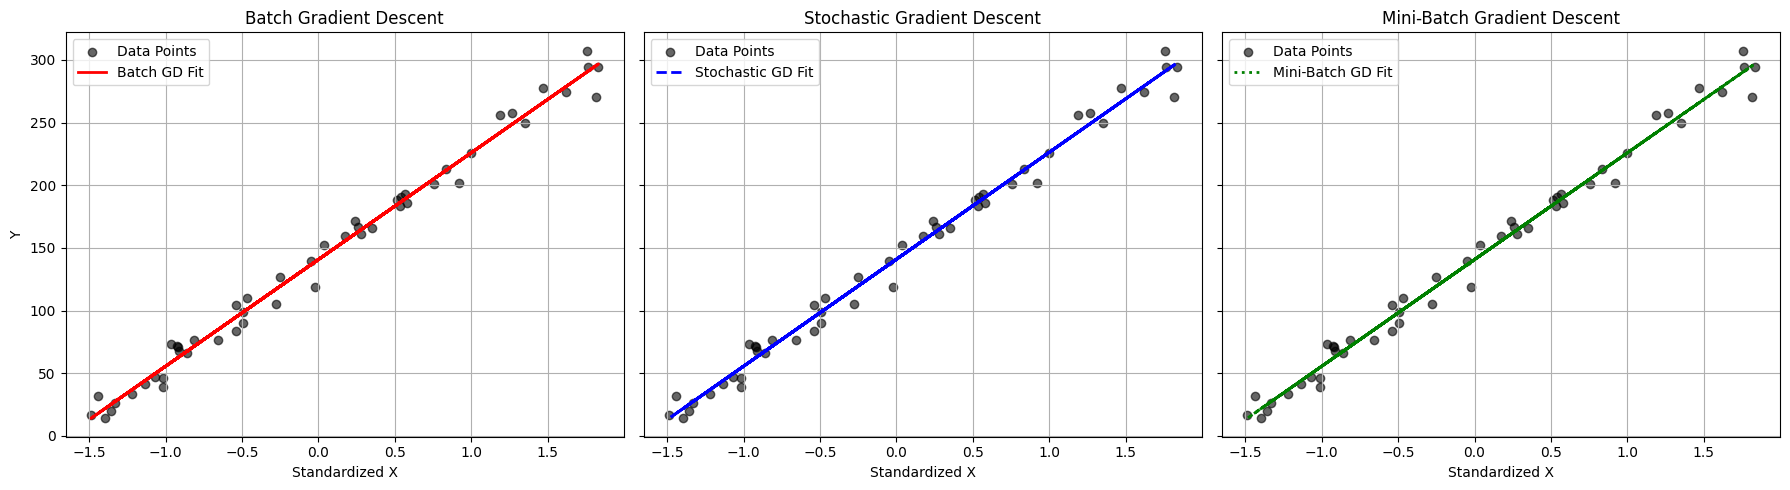

In [33]:
# Regression Fit Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(X_std, y, color='black', alpha=0.6, label='Data Points')
axes[0].plot(X_std, linear_function(X, theta_batch), color='red', linewidth=2, label='Batch GD Fit')
axes[0].set_title('Batch Gradient Descent')
axes[0].set_xlabel('Standardized X')
axes[0].set_ylabel('Y')
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(X_std, y, color='black', alpha=0.6, label='Data Points')
axes[1].plot(X_std, linear_function(X, theta_sgd), color='blue', linestyle='--', linewidth=2, label='Stochastic GD Fit')
axes[1].set_title('Stochastic Gradient Descent')
axes[1].set_xlabel('Standardized X')
axes[1].legend()
axes[1].grid(True)

axes[2].scatter(X_std, y, color='black', alpha=0.6, label='Data Points')
axes[2].plot(X_std, linear_function(X, theta_mb), color='green', linestyle=':', linewidth=2, label='Mini-Batch GD Fit')
axes[2].set_title('Mini-Batch Gradient Descent')
axes[2].set_xlabel('Standardized X')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

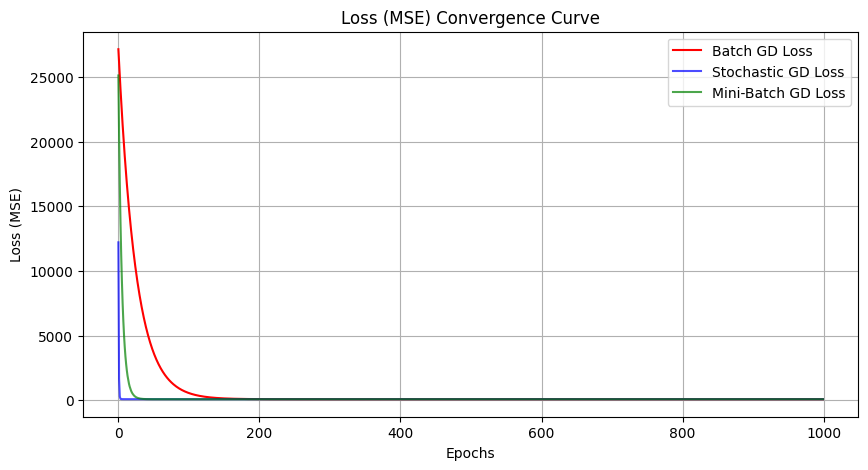

In [34]:
# Plot 2: Loss Convergence Curve
plt.figure(figsize=(10, 5))
plt.plot(loss_batch, label='Batch GD Loss', color='red')
plt.plot(loss_sgd, label='Stochastic GD Loss', color='blue', alpha=0.7)
plt.plot(loss_mb, label='Mini-Batch GD Loss', color='green', alpha=0.7)
plt.title('Loss (MSE) Convergence Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()